# Phase 3: Preprocessing Development

This notebook exercises the preprocessing utilities on the local HAM10000 data. It tests hair removal on a small batch, previews the augmentation pipeline, verifies class balancing, and runs an end-to-end preprocessing pass on 100 images.

The goal is to make preprocessing visible, measurable, and easy to inspect before it becomes part of a training pipeline.

In [2]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from src.preprocessing.augmentation import get_train_transforms, get_val_transforms
from src.preprocessing.class_balancer import get_class_weights
from src.preprocessing.hair_removal import remove_hair_dullrazor

data_root = project_root / "data"
raw_dir = data_root / "raw"
artifact_dir = project_root / "reports" / "artifacts"
figure_dir = project_root / "reports" / "figures"
artifact_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

metadata_df = pd.read_csv(raw_dir / "HAM10000_metadata.csv")
train_split = pd.read_csv(data_root / "splits" / "train_split.csv")
canonical_image_dirs = sorted(path for path in raw_dir.iterdir() if path.is_dir() and path.name.startswith("HAM10000_images_part_"))
image_index = {}
for image_dir in canonical_image_dirs:
    for image_path in image_dir.glob('*.jpg'):
        image_index[image_path.stem] = image_path

print(json.dumps({
    'project_root': str(project_root),
    'train_rows': int(len(train_split)),
    'image_index_size': int(len(image_index)),
}, indent=2))

/home/selba/Desktop/ENSIAS/Mlops/PFA/code/.venv/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


{
  "project_root": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code",
  "train_rows": 6990,
  "image_index_size": 10015
}


Saved hair removal figure to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/preprocessing_hair_removal_before_after.png
Saved hair removal summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/preprocessing_hair_removal_summary.csv


,image_id,dx,hair_density_before,hair_density_after,hair_density_drop
0,ISIC_0032540,nv,0.046130,0.004215,0.041915
1,ISIC_0024924,nv,0.029452,0.002059,0.027393
2,ISIC_0026906,nv,0.017930,0.000774,0.017156
3,ISIC_0033348,nv,0.063033,0.003837,0.059196
4,ISIC_0031139,nv,0.028685,0.000311,0.028374
5,ISIC_0026634,bkl,0.111222,0.004552,0.106670
6,ISIC_0028352,mel,0.074889,0.004730,0.070159
7,ISIC_0031594,nv,0.024056,0.000211,0.023844
8,ISIC_0025441,nv,0.013878,0.000715,0.013163
9,ISIC_0033867,nv,0.015659,0.002467,0.013193


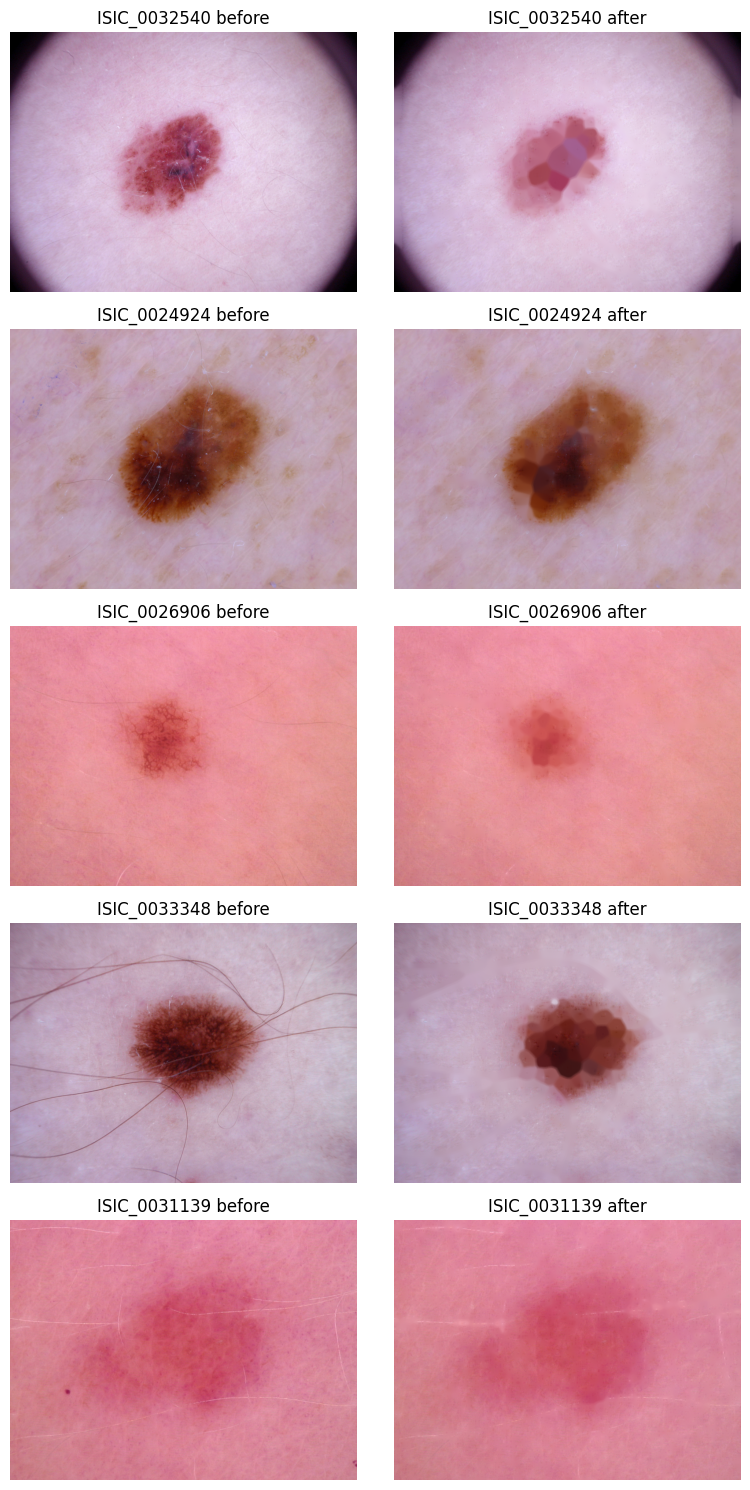

In [3]:
def hair_density(image: np.ndarray) -> float:
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return mask.sum() / (255 * mask.size)

sample_rows = train_split.sample(n=10, random_state=42).reset_index(drop=True)
hair_rows = []
example_pairs = []
for _, row in sample_rows.iterrows():
    image_path = image_index[row['image_id']]
    original = np.array(Image.open(image_path).convert('RGB'))
    cleaned = remove_hair_dullrazor(original)
    hair_rows.append({
        'image_id': row['image_id'],
        'dx': row['dx'],
        'hair_density_before': hair_density(original),
        'hair_density_after': hair_density(cleaned),
    })
    if len(example_pairs) < 5:
        example_pairs.append((row['image_id'], original, cleaned))

hair_df = pd.DataFrame(hair_rows)
hair_df['hair_density_drop'] = hair_df['hair_density_before'] - hair_df['hair_density_after']

fig, axes = plt.subplots(len(example_pairs), 2, figsize=(8, 3 * len(example_pairs)))
for index, (image_id, original, cleaned) in enumerate(example_pairs):
    axes[index, 0].imshow(original)
    axes[index, 0].set_title(f'{image_id} before')
    axes[index, 0].axis('off')
    axes[index, 1].imshow(cleaned)
    axes[index, 1].set_title(f'{image_id} after')
    axes[index, 1].axis('off')

fig.tight_layout()
hair_plot_path = figure_dir / 'preprocessing_hair_removal_before_after.png'
fig.savefig(hair_plot_path, dpi=160, bbox_inches='tight')
hair_report_path = artifact_dir / 'preprocessing_hair_removal_summary.csv'
hair_df.to_csv(hair_report_path, index=False)
print(f'Saved hair removal figure to {hair_plot_path}')
print(f'Saved hair removal summary to {hair_report_path}')
hair_df

/home/selba/Desktop/ENSIAS/Mlops/PFA/code/src/preprocessing/augmentation.py:34: UserWarning: Argument 'fill_value' is not valid and will be ignored.
  A.CoarseDropout(max_holes=8, max_height=INPUT_SIZE // 8, max_width=INPUT_SIZE // 8, fill_value=0, p=0.3),


Saved augmentation preview to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/preprocessing_augmentation_preview.png


PosixPath('/home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/preprocessing_augmentation_preview.png')

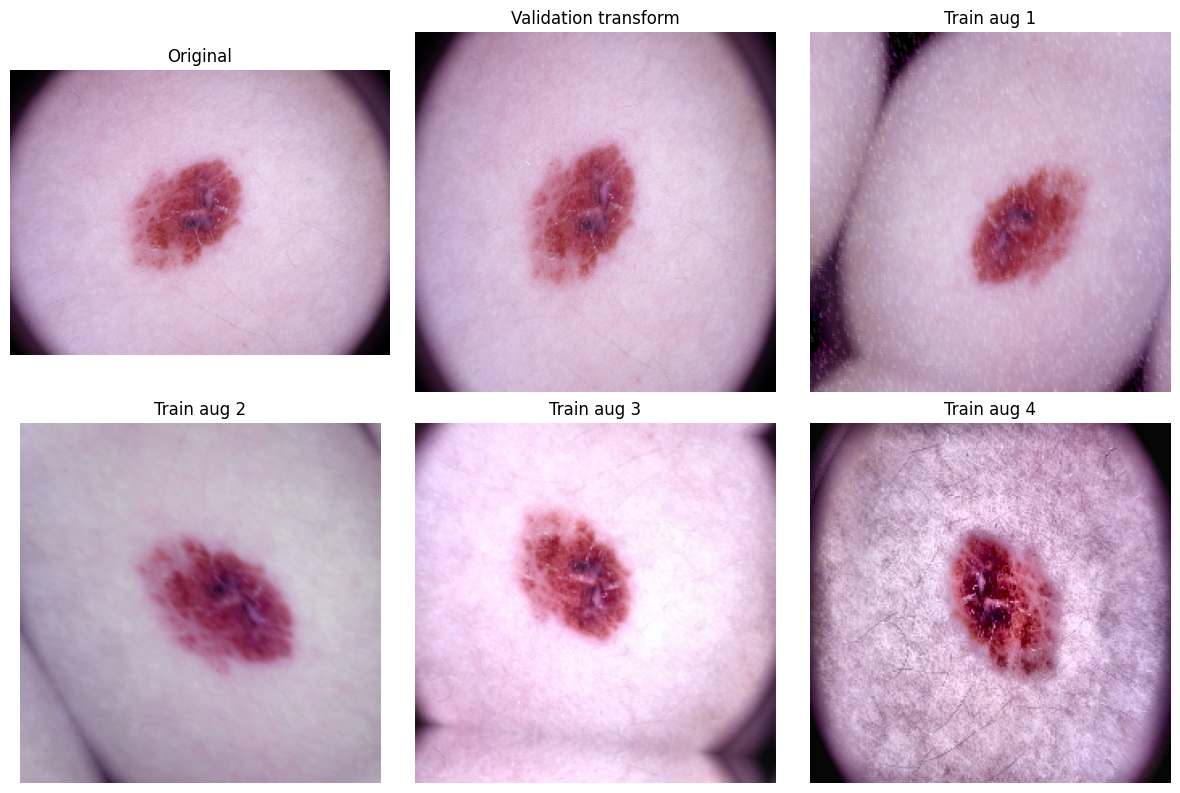

In [4]:
import cv2

train_transforms = get_train_transforms()
val_transforms = get_val_transforms()

aug_source = np.array(Image.open(image_index[sample_rows.iloc[0]['image_id']]).convert('RGB'))
augmented_views = []
for _ in range(4):
    augmented = train_transforms(image=aug_source)['image']
    augmented_np = augmented.permute(1, 2, 0).cpu().numpy()
    augmented_np = augmented_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    augmented_np = np.clip(augmented_np, 0, 1)
    augmented_views.append(augmented_np)

val_view = val_transforms(image=aug_source)['image'].permute(1, 2, 0).cpu().numpy()
val_view = val_view * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
val_view = np.clip(val_view, 0, 1)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
axes[0].imshow(aug_source)
axes[0].set_title('Original')
axes[1].imshow(val_view)
axes[1].set_title('Validation transform')
axes[2].imshow(augmented_views[0])
axes[2].set_title('Train aug 1')
axes[3].imshow(augmented_views[1])
axes[3].set_title('Train aug 2')
axes[4].imshow(augmented_views[2])
axes[4].set_title('Train aug 3')
axes[5].imshow(augmented_views[3])
axes[5].set_title('Train aug 4')
for ax in axes:
    ax.axis('off')
fig.tight_layout()
augmentation_plot_path = figure_dir / 'preprocessing_augmentation_preview.png'
fig.savefig(augmentation_plot_path, dpi=160, bbox_inches='tight')
print(f'Saved augmentation preview to {augmentation_plot_path}')
augmentation_plot_path

In [5]:
labels = train_split['label'].astype(int).tolist()
weights_effective = get_class_weights(labels, strategy='effective_num', beta=0.995)
weights_inverse = get_class_weights(labels, strategy='inverse_freq')
class_counts = train_split['label'].value_counts().sort_index()
weight_summary = {
    'train_class_counts': class_counts.to_dict(),
    'effective_num_weights': weights_effective.tolist(),
    'inverse_freq_weights': weights_inverse.tolist(),
    'effective_num_ratio_mel_to_benign': float(weights_effective[1] / weights_effective[0]),
    'inverse_freq_ratio_mel_to_benign': float(weights_inverse[1] / weights_inverse[0]),
}

print(json.dumps(weight_summary, indent=2))
weights_effective

{
  "train_class_counts": {
    "0": 6219,
    "1": 771
  },
  "effective_num_weights": [
    0.9894039630889893,
    1.0105960369110107
  ],
  "inverse_freq_weights": [
    0.22060085833072662,
    1.7793991565704346
  ],
  "effective_num_ratio_mel_to_benign": 1.0214190483093262,
  "inverse_freq_ratio_mel_to_benign": 8.066147804260254
}


tensor([0.9894, 1.0106])

Saved pipeline preview to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/preprocessing_pipeline_preview.png
Saved pipeline summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/preprocessing_pipeline_summary.json


{'processed_images': 100, 'shape_summary': {'(3, 224, 224)': 100}}

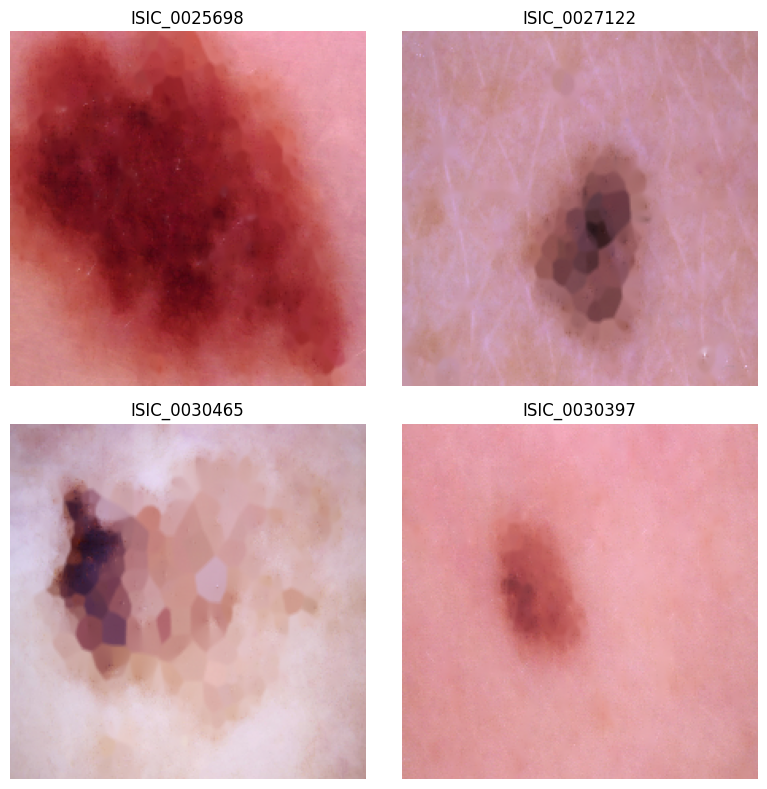

In [6]:
sample_100 = train_split.sample(n=100, random_state=7).reset_index(drop=True)
processed_shapes = []
processed_preview = []
for _, row in sample_100.iterrows():
    image_path = image_index[row['image_id']]
    original = np.array(Image.open(image_path).convert('RGB'))
    cleaned = remove_hair_dullrazor(original)
    transformed = val_transforms(image=cleaned)['image']
    processed_shapes.append(tuple(transformed.shape))
    if len(processed_preview) < 4:
        preview = transformed.permute(1, 2, 0).cpu().numpy()
        preview = preview * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        preview = np.clip(preview, 0, 1)
        processed_preview.append((row['image_id'], preview))

shape_summary = pd.Series(processed_shapes).value_counts().to_dict()

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()
for axis, (image_id, preview) in zip(axes, processed_preview):
    axis.imshow(preview)
    axis.set_title(image_id)
    axis.axis('off')
fig.tight_layout()
pipeline_preview_path = figure_dir / 'preprocessing_pipeline_preview.png'
fig.savefig(pipeline_preview_path, dpi=160, bbox_inches='tight')

pipeline_summary = {
    'processed_images': int(len(sample_100)),
    'shape_summary': {str(key): int(value) for key, value in shape_summary.items()},
}
pipeline_summary_path = artifact_dir / 'preprocessing_pipeline_summary.json'
pipeline_summary_path.write_text(json.dumps(pipeline_summary, indent=2), encoding='utf-8')
print(f'Saved pipeline preview to {pipeline_preview_path}')
print(f'Saved pipeline summary to {pipeline_summary_path}')
pipeline_summary